<a href="https://colab.research.google.com/github/sohailpk84-max/pakgeek/blob/main/MSCKDProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving ckd_real_400_plus_synthetic_10000.csv to ckd_real_400_plus_synthetic_10000.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10400 entries, 0 to 10399
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       10400 non-null  int64  
 1   age                      10400 non-null  float64
 2   blood_pressure           10400 non-null  float64
 3   specific_gravity         10400 non-null  float64
 4   albumin                  10400 non-null  float64
 5   sugar                    10400 non-null  float64
 6   red_blood_cells          10400 non-null  int64  
 7   pus_cell                 10400 non-null  int64  
 8   pus_cell_clumps          10400 non-null  int64  
 9   bacteria                 10400 non-null  int64  
 10  blood_glucose_random     10400 non-null  float64
 11  blood_urea               10400 non-null  float64
 12  serum_creatinine         10400 non-null  flo

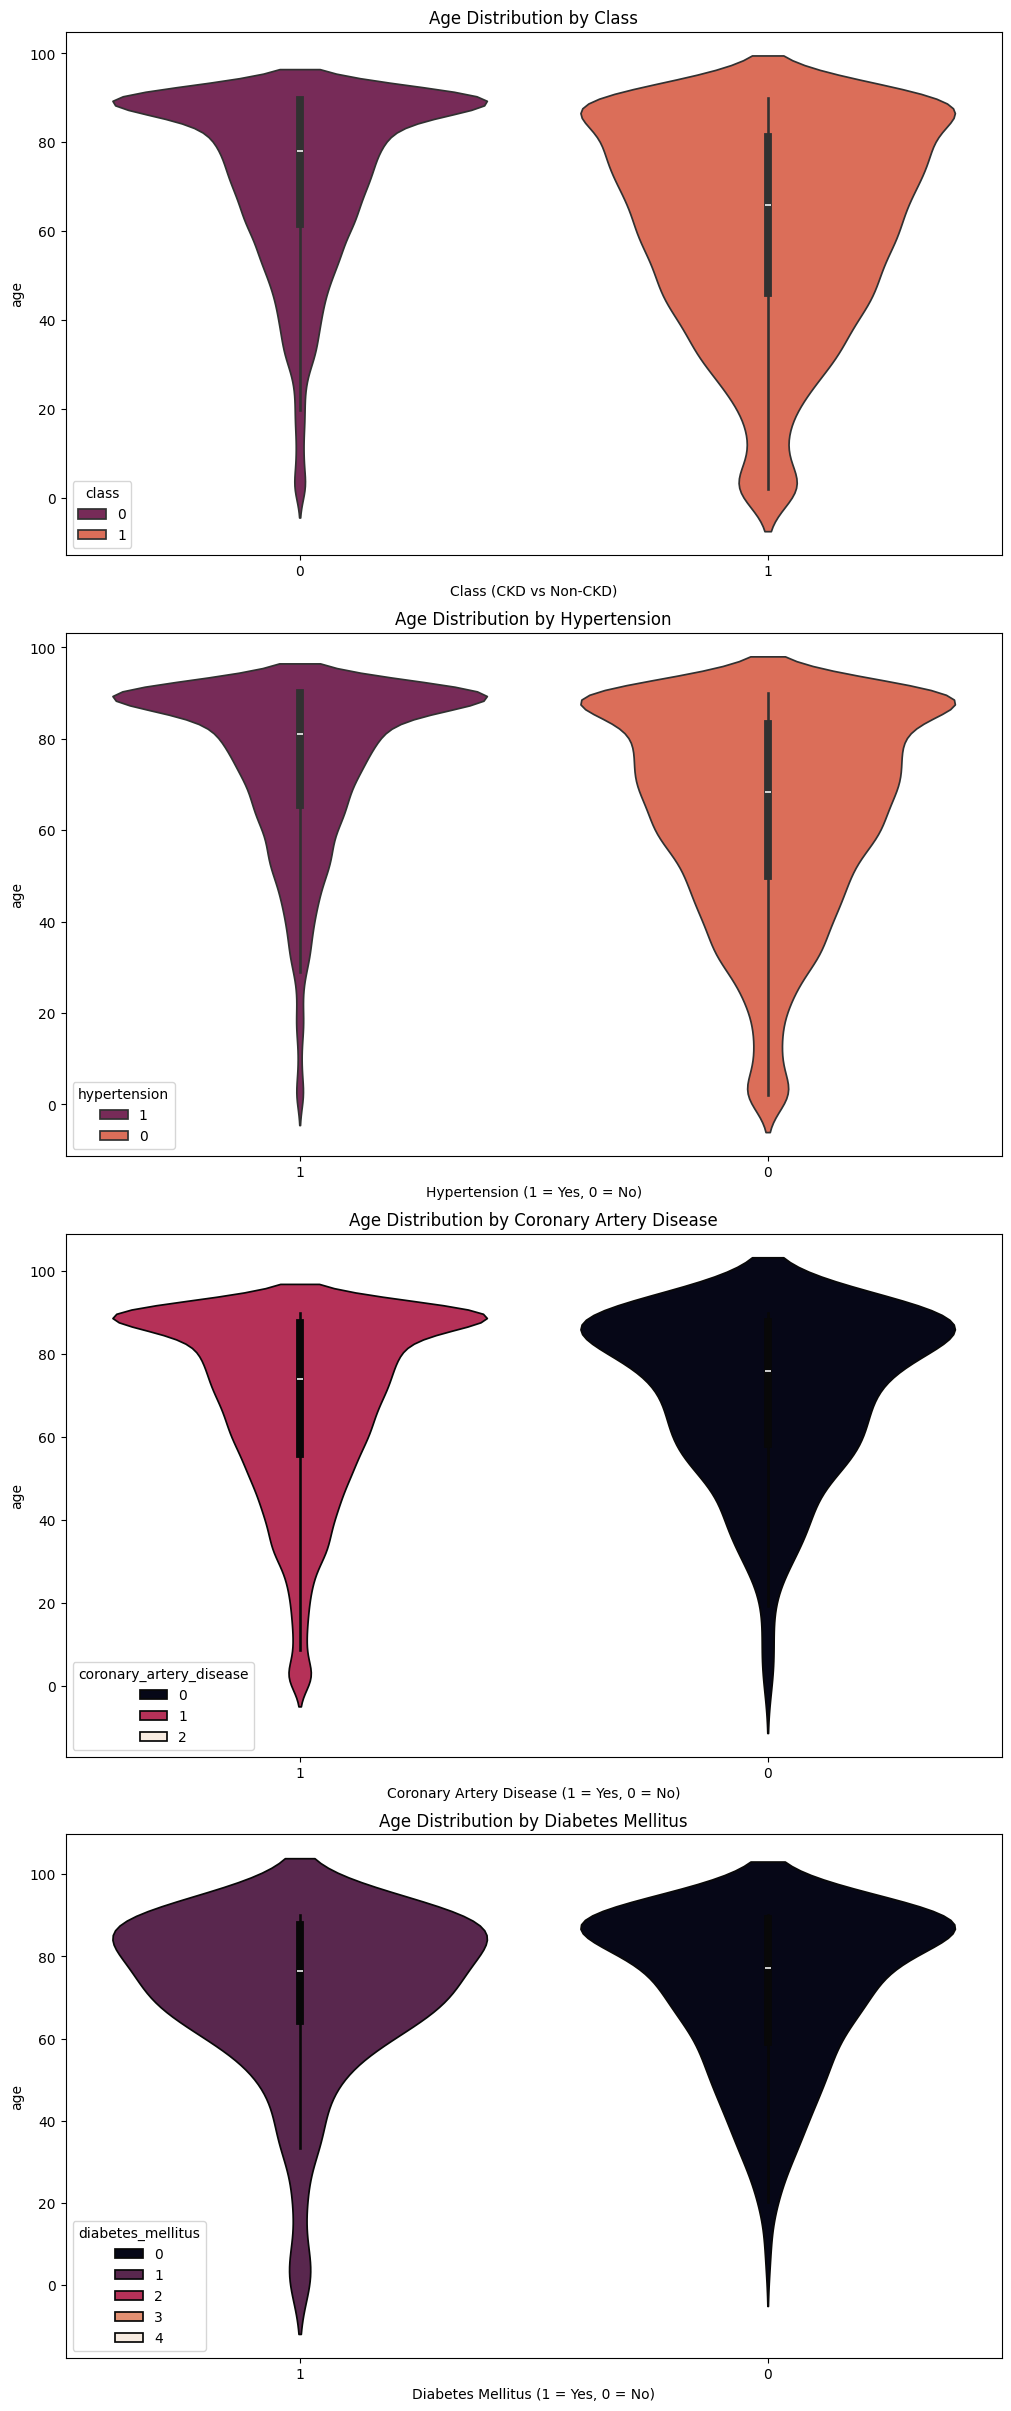

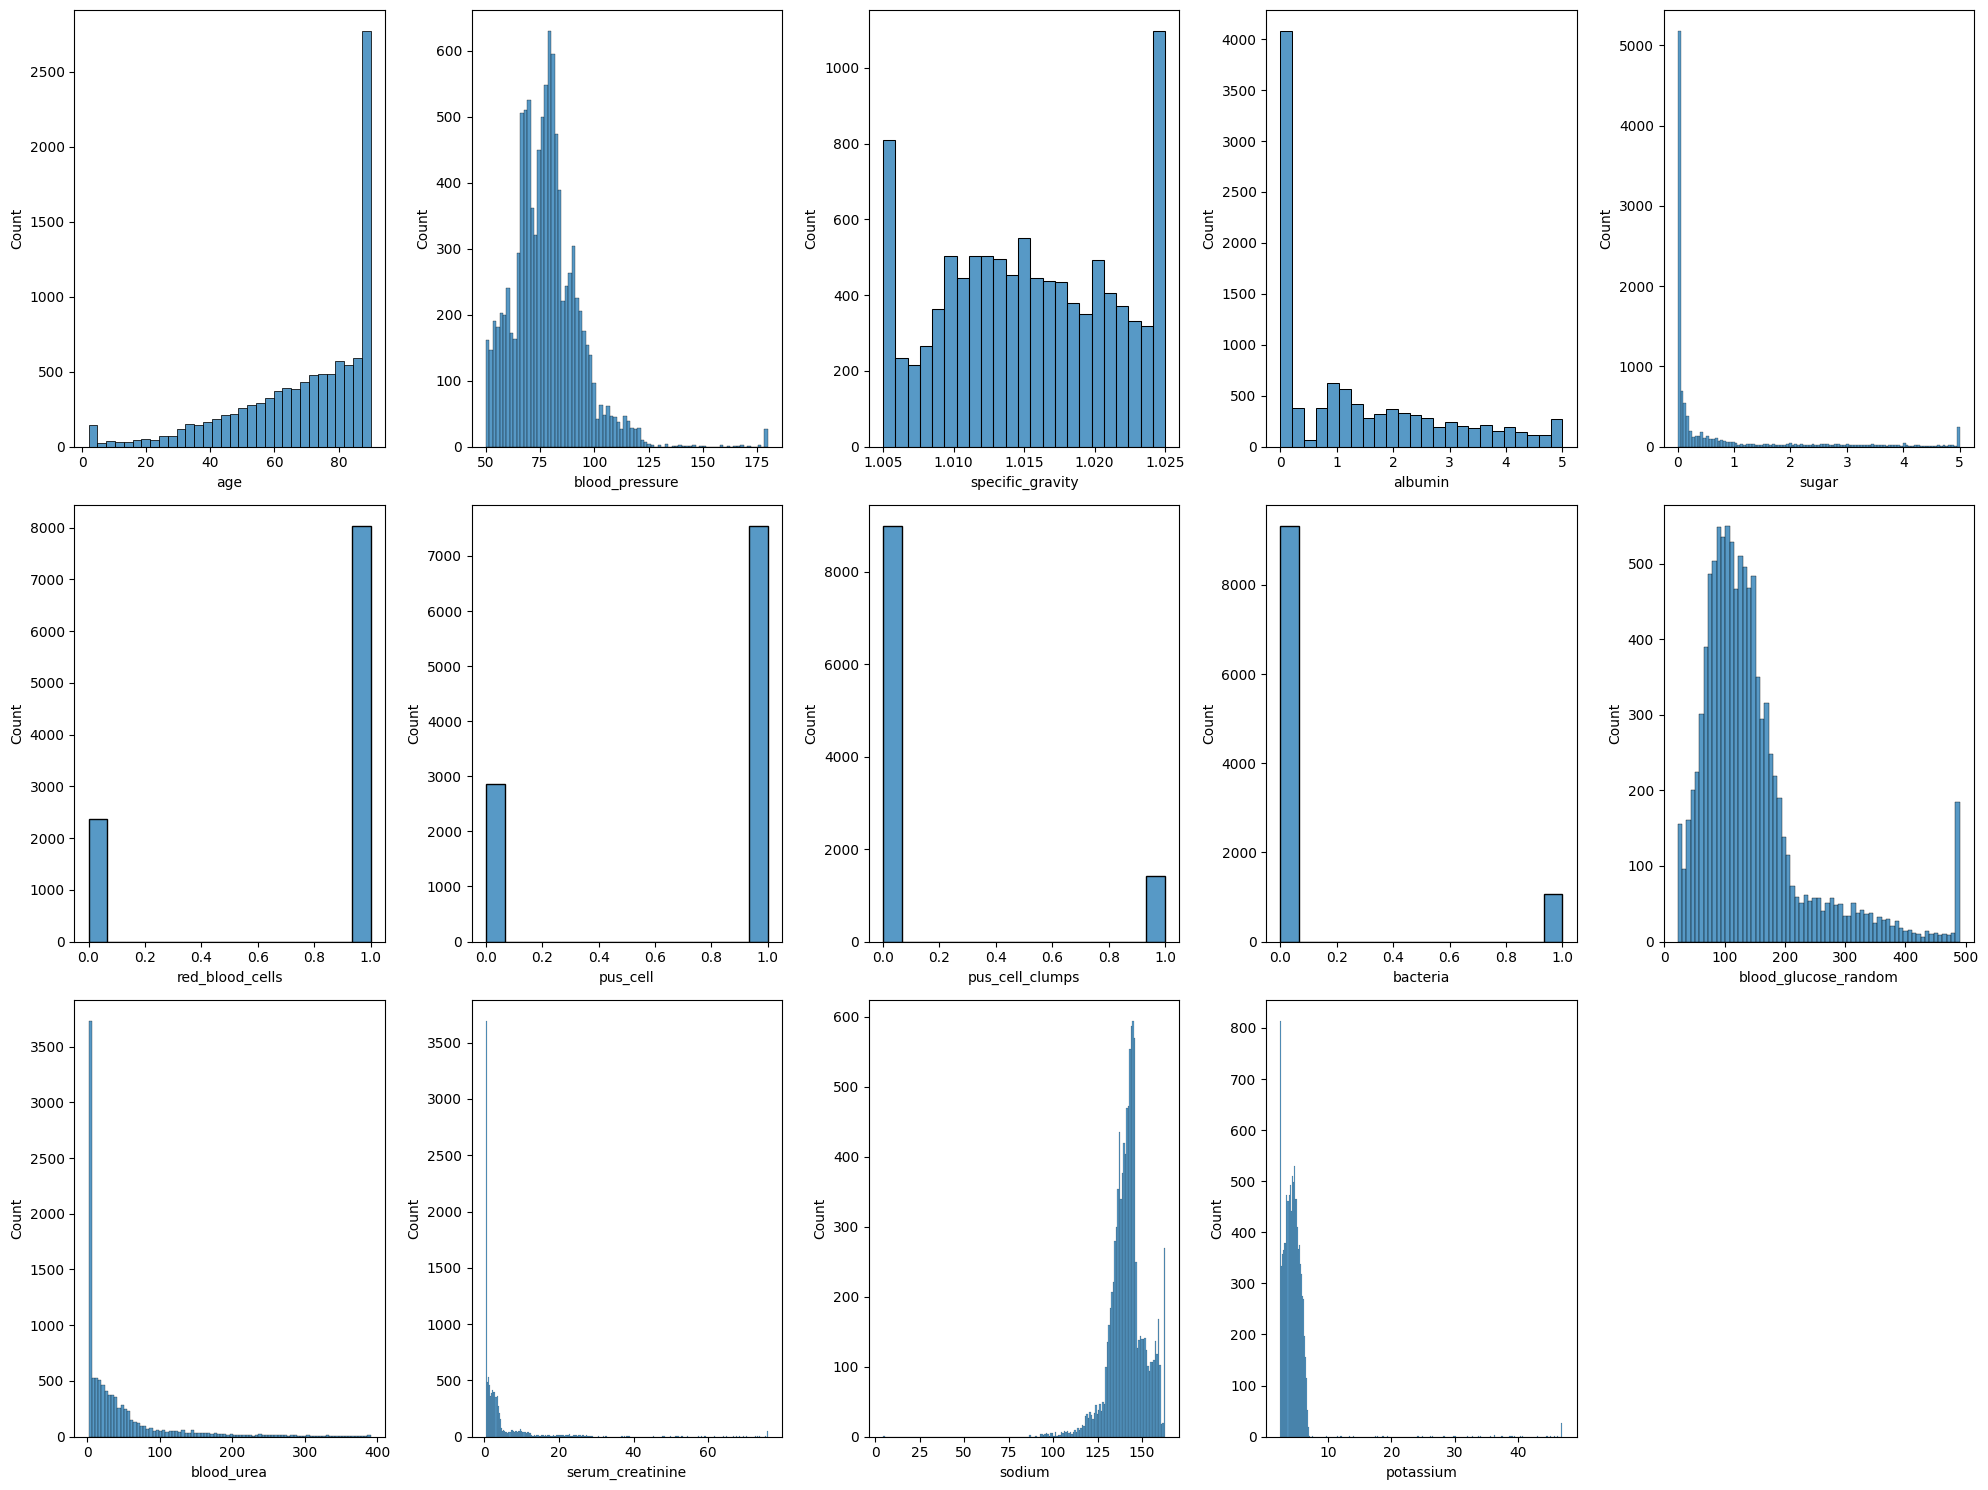

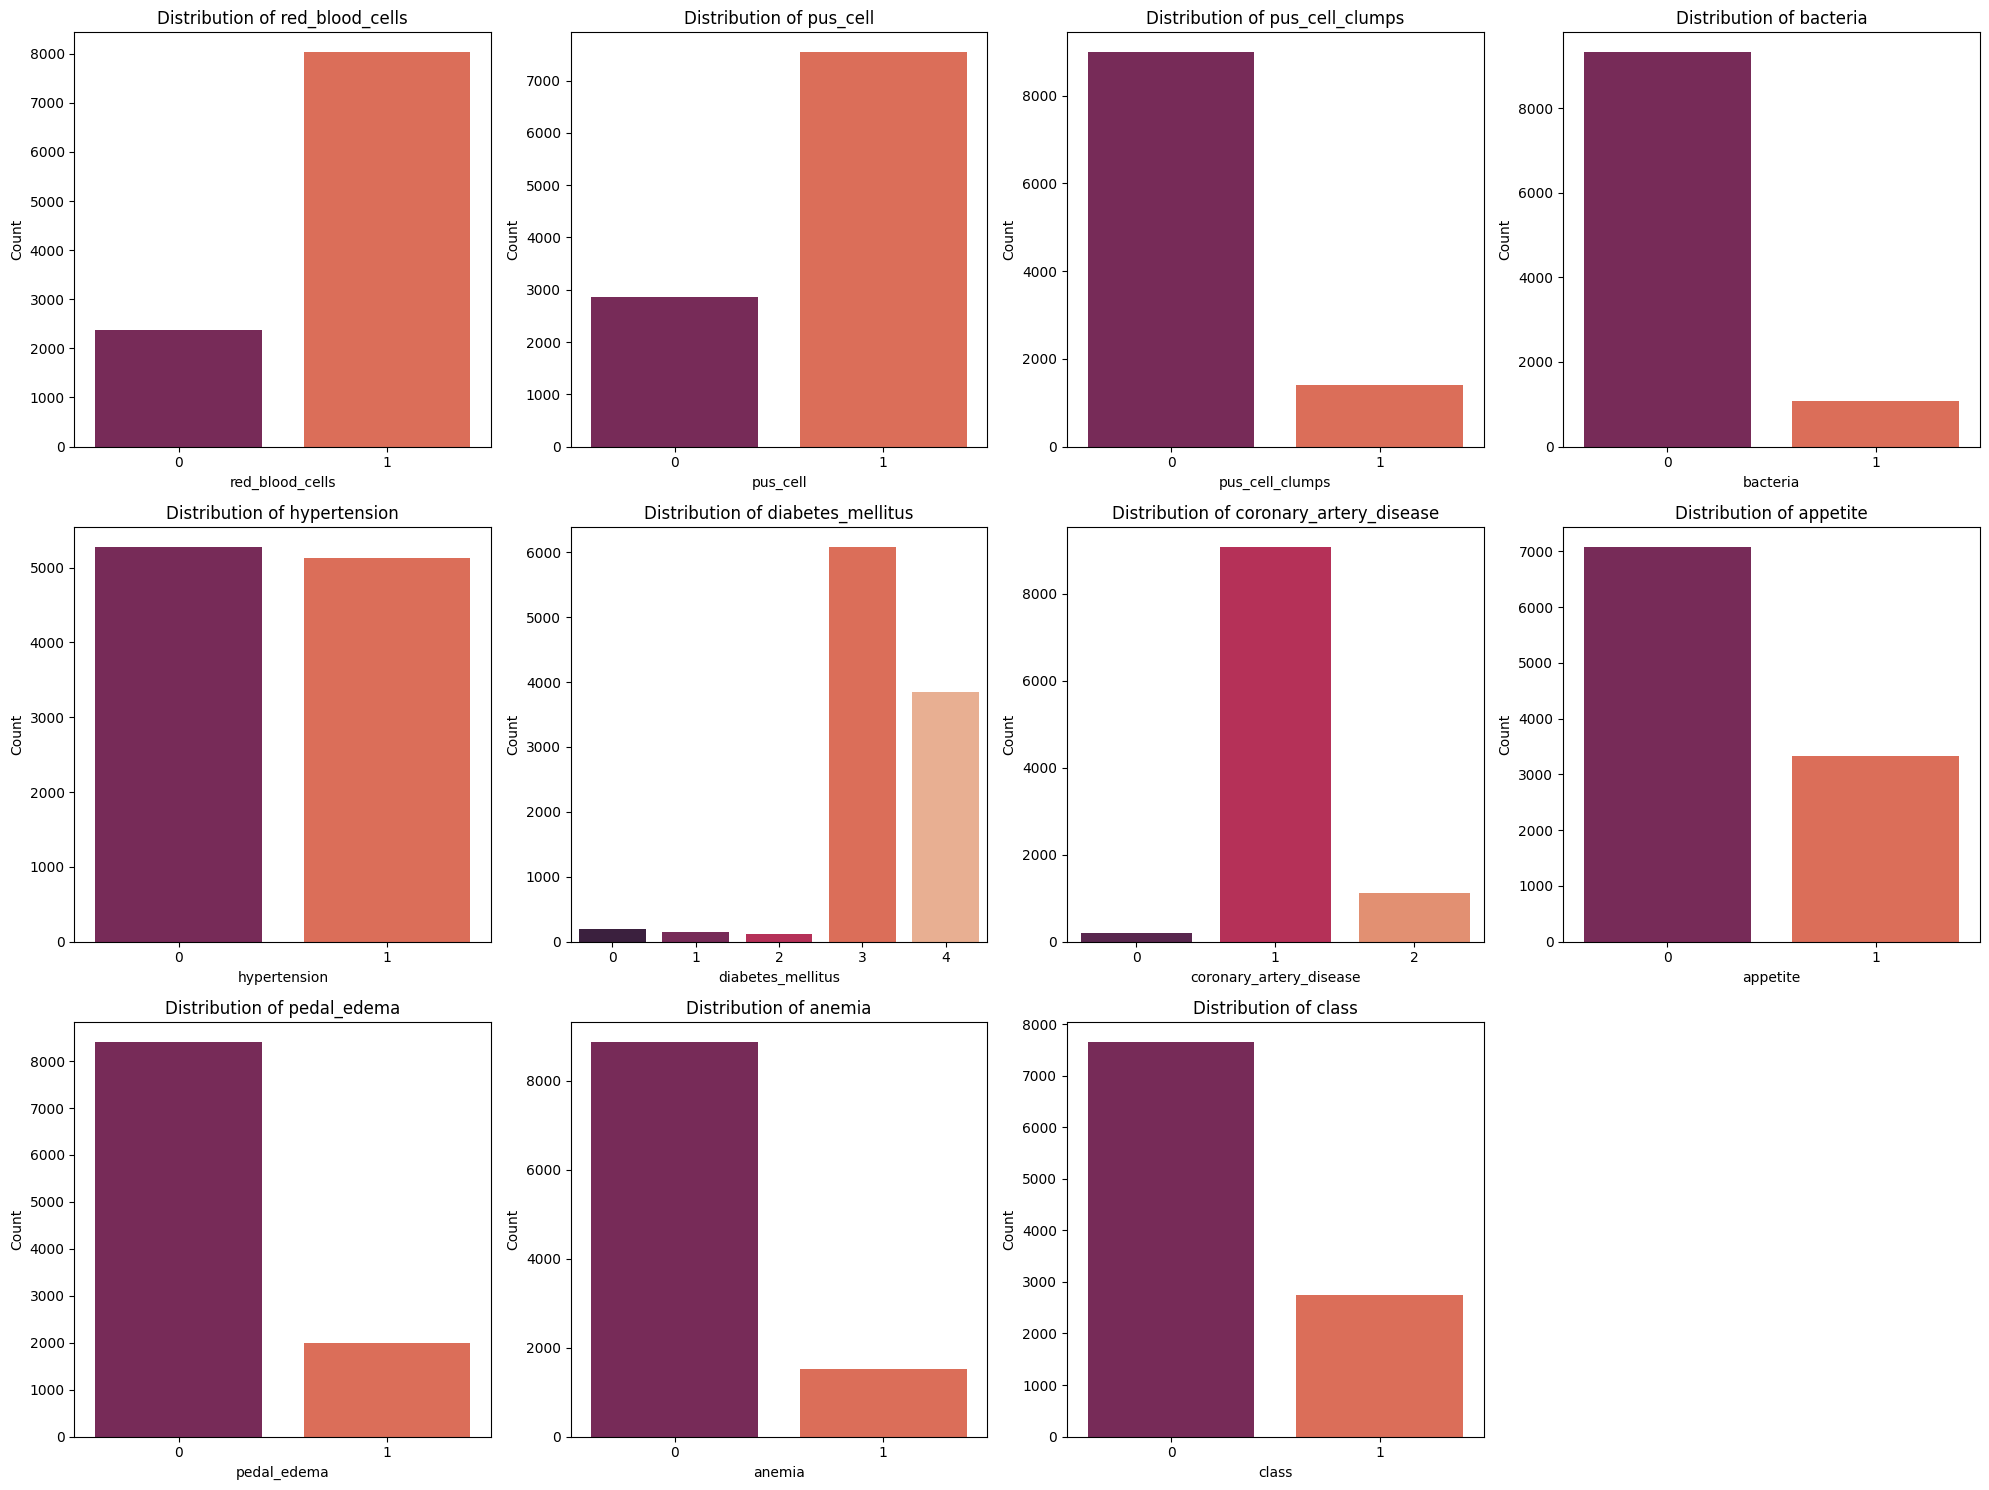

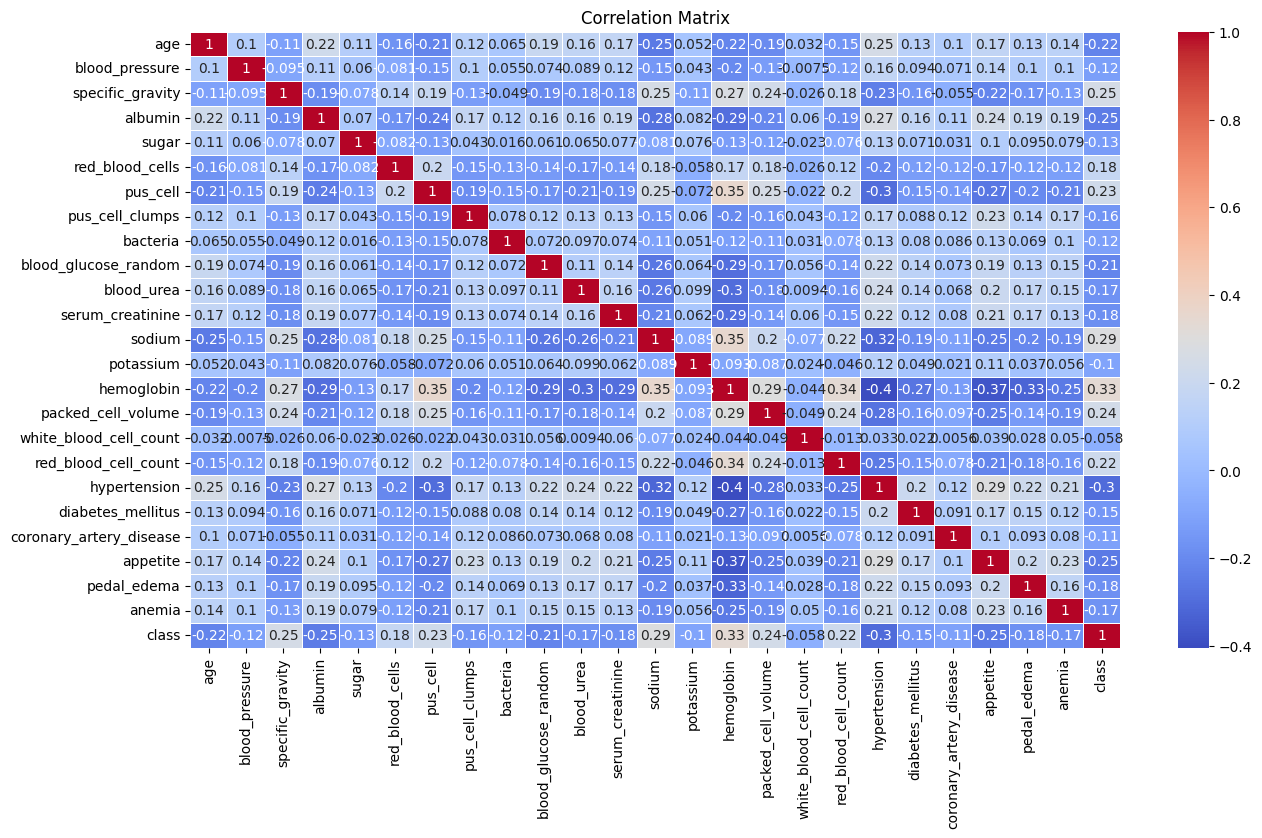

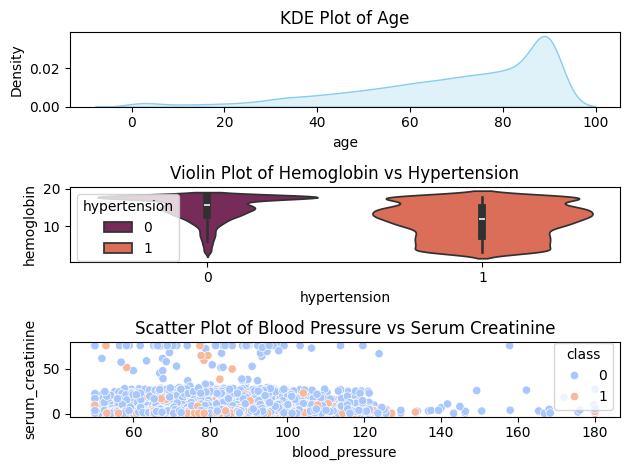

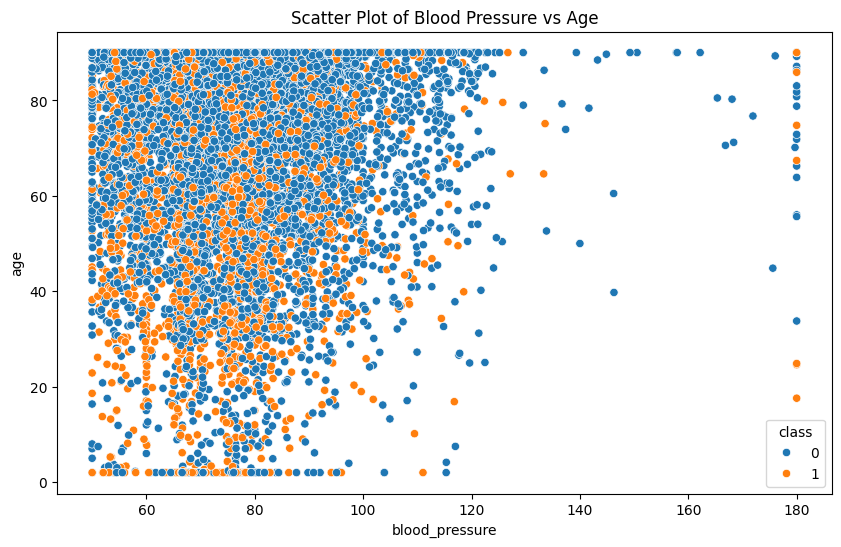

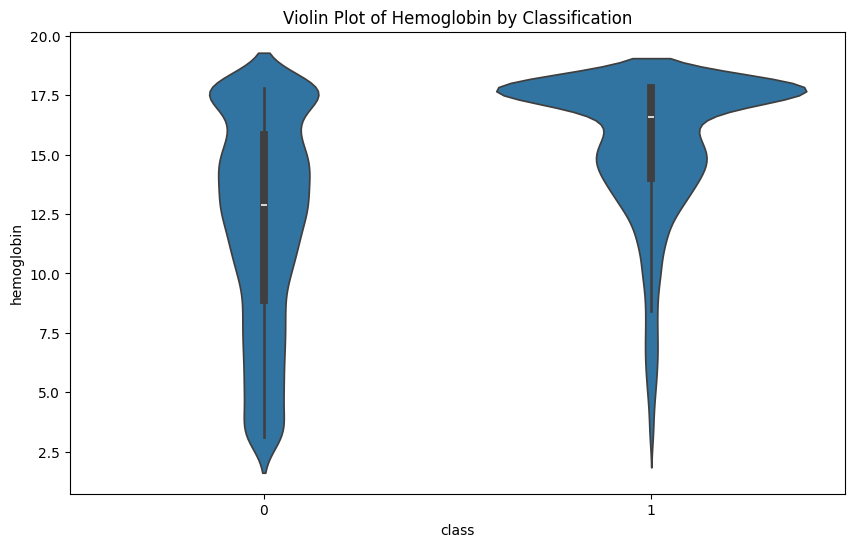

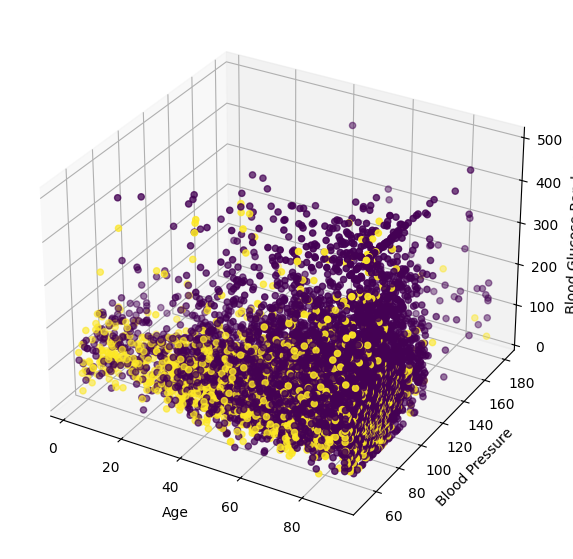

Training set: (6240, 24), (6240,)
Validation set: (2080, 24), (2080,)
Test set: (2080, 24), (2080,)

Processing: Bagging
Top 3 features for Bagging: ['blood_glucose_random', 'blood_pressure', 'sodium']
Selected features for Bagging: ['blood_glucose_random', 'blood_pressure', 'sodium', 'potassium', 'diabetes_mellitus']
Best parameters for Bagging: {'estimator__max_depth': 10, 'n_estimators': 50}
Best CV accuracy for Bagging: 0.7671

Processing: Gradient Boosting
Top 3 features for Gradient Boosting: ['sodium', 'blood_glucose_random', 'age']
Selected features for Gradient Boosting: ['sodium', 'blood_glucose_random', 'age', 'specific_gravity', 'hemoglobin', 'blood_pressure', 'hypertension', 'sugar', 'blood_urea', 'bacteria']
Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV accuracy for Gradient Boosting: 0.7944

Processing: AdaBoost
Top 3 features for AdaBoost: ['sodium', 'specific_gravity', 'blood_glucose_random']
Selected feature

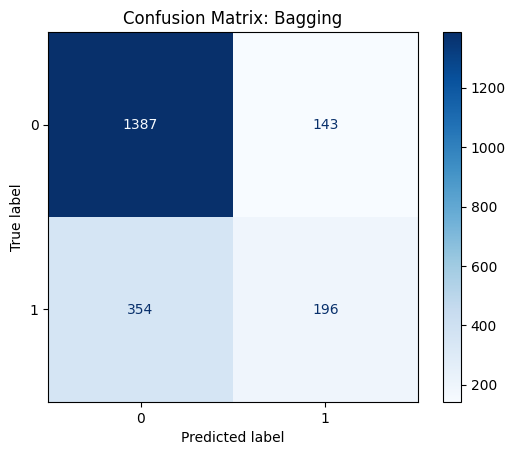

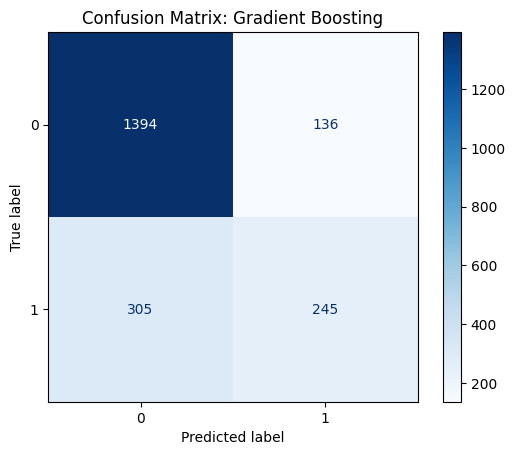

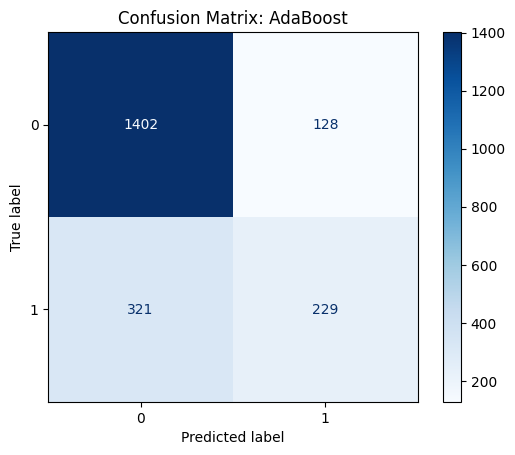

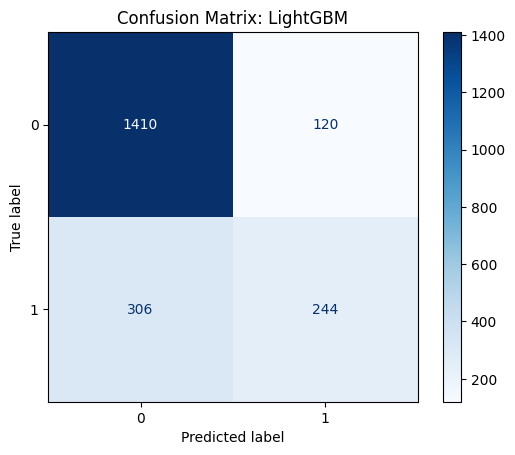

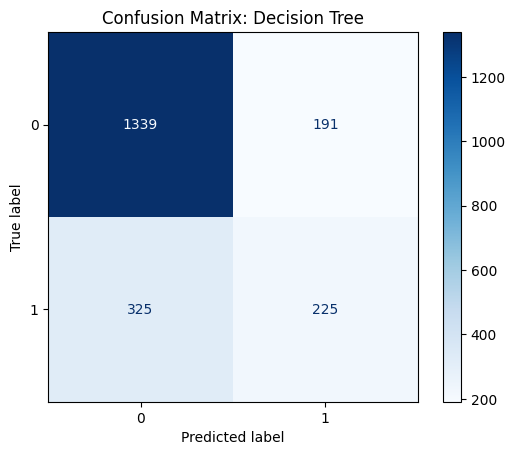

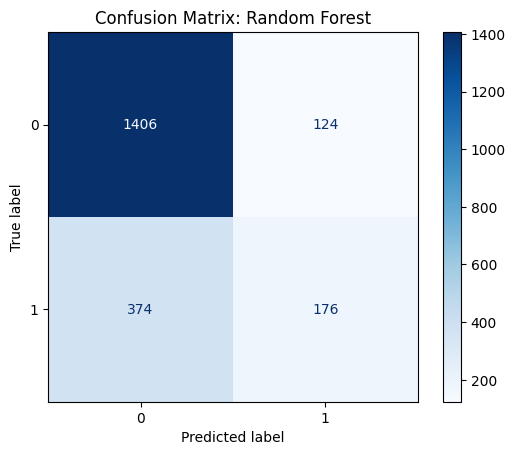

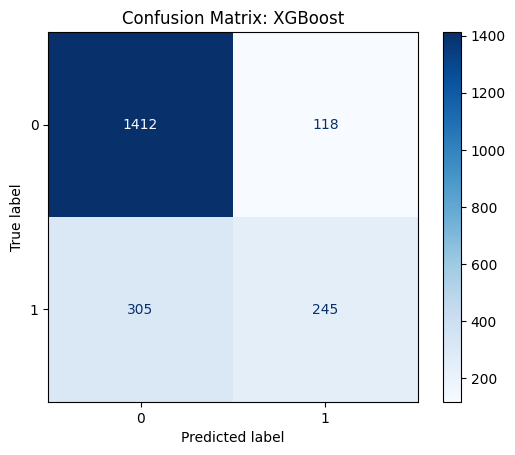

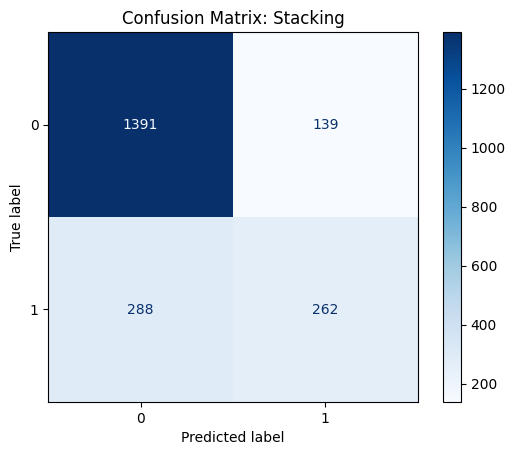

+----+--------+-------------------+------------+-------------+----------+------------+-----------+
|    |   Rank | Model             |   Accuracy |   Precision |   Recall |   F1-Score |   ROC-AUC |
+====+========+===================+============+=============+==========+============+===========+
|  0 |      1 | XGBoost           |   0.796635 |    0.674931 | 0.445455 |   0.536692 |  0.826003 |
+----+--------+-------------------+------------+-------------+----------+------------+-----------+
|  1 |      2 | LightGBM          |   0.795192 |    0.67033  | 0.443636 |   0.533917 |  0.82458  |
+----+--------+-------------------+------------+-------------+----------+------------+-----------+
|  2 |      3 | Stacking          |   0.794712 |    0.653367 | 0.476364 |   0.550999 |  0.826482 |
+----+--------+-------------------+------------+-------------+----------+------------+-----------+
|  3 |      4 | Gradient Boosting |   0.787981 |    0.643045 | 0.445455 |   0.526316 |  0.810496 |
+----+----

In [1]:
# Import necessary libraries
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    StackingClassifier,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Load the dataset
"""file_path = "/content/ckd_real_400_plus_synthetic_10000.csv"
"""
uploaded = files.upload()
file_path = next(iter(uploaded))
data = pd.read_csv(file_path)

data.info()

#######################################
# Rename columns for clarity
column_mapping = {
    'age': 'age',
    'bp': 'blood_pressure',
    'sg': 'specific_gravity',
    'al': 'albumin',
    'su': 'sugar',
    'rbc': 'red_blood_cells',
    'pc': 'pus_cell',
    'pcc': 'pus_cell_clumps',
    'ba': 'bacteria',
    'bgr': 'blood_glucose_random',
    'bu': 'blood_urea',
    'sc': 'serum_creatinine',
    'sod': 'sodium',
    'pot': 'potassium',
    'hemo': 'hemoglobin',
    'pcv': 'packed_cell_volume',
    'wc': 'white_blood_cell_count',
    'rc': 'red_blood_cell_count',
    'htn': 'hypertension',
    'dm': 'diabetes_mellitus',
    'cad': 'coronary_artery_disease',
    'appet': 'appetite',
    'pe': 'pedal_edema',
    'ane': 'anemia',
    'classification': 'class'
}

data.rename(columns=column_mapping, inplace=True)

#######################################
# Data Preprocessing

if "id" in data.columns:
    data.drop(columns=["id"], inplace=True)
    print("'id' column removed.")

# Handle missing values
for col in data.columns:
    if data[col].dtype == "object":
        data[col].fillna(data[col].mode()[0], inplace=True)
    else:
        data[col].fillna(data[col].mean(), inplace=True)

# Label encoding for categorical variables
categorical_cols = data.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

########################################################################

# Create a vertical layout with subplots
fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(10, 24),
    constrained_layout=True
)

# Violin plot for 'class' vs. 'age'
sns.violinplot(
    ax=axes[0],
    x='class',
    y='age',
    hue='class',
    data=data,
    palette='rocket',
    order=[0, 1]
)
axes[0].set_title("Age Distribution by Class")
axes[0].set_xlabel("Class (CKD vs Non-CKD)")

# Violin plot for 'hypertension' vs. 'age'
sns.violinplot(
    ax=axes[1],
    x='hypertension',
    y='age',
    hue='hypertension',
    data=data,
    palette='rocket',
    hue_order=[1, 0],
    order=[1, 0]
)
axes[1].set_title("Age Distribution by Hypertension")
axes[1].set_xlabel("Hypertension (1 = Yes, 0 = No)")

# Violin plot for 'coronary_artery_disease' vs. 'age'
sns.violinplot(
    ax=axes[2],
    x='coronary_artery_disease',
    y='age',
    hue='coronary_artery_disease',
    data=data,
    palette='rocket',
    hue_order=[1, 0],
    order=[1, 0]
)
axes[2].set_title("Age Distribution by Coronary Artery Disease")
axes[2].set_xlabel("Coronary Artery Disease (1 = Yes, 0 = No)")

# Violin plot for 'diabetes_mellitus' vs. 'age'
sns.violinplot(
    ax=axes[3],
    x='diabetes_mellitus',
    y='age',
    hue='diabetes_mellitus',
    data=data,
    palette='rocket',
    hue_order=[1, 0],
    order=[1, 0]
)
axes[3].set_title("Age Distribution by Diabetes Mellitus")
axes[3].set_xlabel("Diabetes Mellitus (1 = Yes, 0 = No)")

plt.show()

# Numeric Features Histogram
plt.figure(figsize=(20, 15))
plotnumber = 1

for col in data.columns:
    if data[col].dtype != 'object':
        if plotnumber <= 14:
            ax = plt.subplot(3, 5, plotnumber)
            sns.histplot(data[col])
            plt.xlabel(col)
        plotnumber += 1

plt.tight_layout()
plt.show()

# Categorical Features Count Plot
categorical_cols = [
    col for col in data.columns
    if data[col].nunique() < 20
]

if len(categorical_cols) == 0:
    print("No categorical-like columns detected in the dataset!")
else:
    num_cols = 4
    num_rows = -(-len(categorical_cols) // num_cols)

    plt.figure(figsize=(20, 5 * num_rows))

    for i, col in enumerate(categorical_cols, 1):
        plt.subplot(num_rows, num_cols, i)
        sns.countplot(
            data=data,
            x=col,
            palette='rocket'
        )
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel('Count')

    plt.tight_layout()
    plt.show()

# Heatmap of Correlations
plt.figure(figsize=(15, 8))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

# KDE Plot for age
plt.subplot(3, 1, 1)
sns.kdeplot(
    data['age'],
    fill=True,
    color='skyblue'
)
plt.title("KDE Plot of Age")

# Violin Plot for Hemoglobin and Hypertension
plt.subplot(3, 1, 2)
sns.violinplot(
    x='hypertension',
    y='hemoglobin',
    hue='hypertension',
    data=data,
    palette='rocket'
)
plt.title("Violin Plot of Hemoglobin vs Hypertension")

# Scatter Plot of blood_pressure vs. serum_creatinine
plt.subplot(3, 1, 3)
sns.scatterplot(
    x='blood_pressure',
    y='serum_creatinine',
    hue='class',
    data=data,
    palette='coolwarm'
)
plt.title("Scatter Plot of Blood Pressure vs Serum Creatinine")

plt.tight_layout()
plt.show()

# Scatter Plot of blood_pressure vs. age by class
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='blood_pressure',
    y='age',
    hue='class',
    data=data
)

plt.title("Scatter Plot of Blood Pressure vs Age")
plt.show()

# Violin Plot of hemoglobin by class
plt.figure(figsize=(10, 6))

sns.violinplot(
    x='class',
    y='hemoglobin',
    data=data
)

plt.title("Violin Plot of Hemoglobin by Classification")
plt.show()

# Pair Plot
# sns.pairplot(data, hue='class', diag_kind='kde')
# plt.show()

# 3D Scatter Plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.scatter(
    data['age'],
    data['blood_pressure'],
    data['blood_glucose_random'],
    c=pd.factorize(data['class'])[0],
    cmap='viridis'
)

ax.set_xlabel('Age')
ax.set_ylabel('Blood Pressure')
ax.set_zlabel('Blood Glucose Random')

plt.show()


#######################################################################

# Feature and target separation
X = data.drop(columns=["class"])
y = data["class"]

# Train-validation-test split (60:20:20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Print the dataset sizes
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

# Feature weighting based on Random Forest importance
rf_model = RandomForestClassifier(
    random_state=42
).fit(
    X_train,
    y_train
)

feature_weights = (
    rf_model.feature_importances_
    / rf_model.feature_importances_.sum()
)

X_train_weighted = X_train.copy()
X_val_weighted = X_val.copy()
X_test_weighted = X_test.copy()

for i, col in enumerate(X_train.columns):
    X_train_weighted[col] *= feature_weights[i]
    X_val_weighted[col] *= feature_weights[i]
    X_test_weighted[col] *= feature_weights[i]


# Top-3 features based on accuracy
def select_top_k_features(X, y, k, model):

    feature_scores = {}

    for feature in X.columns:

        X_single = X[[feature]]

        model_clone = clone(model)

        model_clone.fit(
            X_single,
            y
        )

        y_pred = model_clone.predict(
            X_single
        )

        acc = accuracy_score(
            y,
            y_pred
        )

        feature_scores[feature] = acc

    sorted_features = sorted(
        feature_scores,
        key=feature_scores.get,
        reverse=True
    )

    return sorted_features[:k]


# Forward selection
def forward_selection(X, y, initial_features, model):

    selected_features = list(initial_features)

    remaining_features = list(
        set(X.columns) - set(initial_features)
    )

    best_accuracy = 0

    while remaining_features:

        feature_to_add = None

        for feature in remaining_features:

            current_features = (
                selected_features + [feature]
            )

            model_clone = clone(model)

            model_clone.fit(
                X[current_features],
                y
            )

            y_pred = model_clone.predict(
                X[current_features]
            )

            acc = accuracy_score(
                y,
                y_pred
            )

            if acc > best_accuracy:
                best_accuracy = acc
                feature_to_add = feature

        if feature_to_add:

            selected_features.append(
                feature_to_add
            )

            remaining_features.remove(
                feature_to_add
            )

        else:
            break

    return selected_features


# Models and parameters
models = {

    "Bagging":
        BaggingClassifier(
            estimator=DecisionTreeClassifier(),
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "AdaBoost":
        AdaBoostClassifier(
            random_state=42
        ),

    "LightGBM":
        LGBMClassifier(
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            eval_metric="logloss",
            random_state=42
        ),
}


param_grids = {

    "Bagging": {

        "n_estimators":
            [10, 50, 100],

        "estimator__max_depth":
            [3, 5, 10],
    },


    "Gradient Boosting": {

        "n_estimators":
            [50, 100],

        "learning_rate":
            [0.05, 0.1, 0.2],

        "max_depth":
            [3, 5],
    },


    "AdaBoost": {

        "n_estimators":
            [50, 100],

        "learning_rate":
            [0.05, 0.1, 0.2],
    },


    "LightGBM": {

        "n_estimators":
            [50, 100],

        "learning_rate":
            [0.05, 0.1, 0.2],

        "max_depth":
            [3, 5],
    },


    "Random Forest": {

        "n_estimators":
            [50, 100],

        "max_depth":
            [3, 5, 10],

        "min_samples_split":
            [2, 5, 10],
    },


    "Decision Tree": {

        "max_depth":
            [3, 5, 10],

        "min_samples_split":
            [2, 5, 10],
    },


    # ==========================================================
    # XGBOOST HYPERPARAMETER GRID
    # ==========================================================
    #
    # This is the added proposal:
    # XGBoost is now tuned through GridSearchCV instead
    # of being trained only once with its default parameters.
    #
    "XGBoost": {

        "n_estimators":
            [50, 100, 200],

        "max_depth":
            [3, 5, 7],

        "learning_rate":
            [0.05, 0.1, 0.2],

        "subsample":
            [0.8, 1.0],

        "colsample_bytree":
            [0.8, 1.0]
    }
}


# ==========================================================
# Training and tuning models
# ==========================================================

best_estimators = {}

selected_features_per_model = {}


for model_name, model in models.items():

    try:

        print("\n" + "=" * 70)
        print(f"Processing: {model_name}")
        print("=" * 70)

        # Select top 3 features
        top_3_features = select_top_k_features(
            X_train_weighted,
            y_train,
            3,
            model
        )

        print(
            f"Top 3 features for {model_name}: "
            f"{top_3_features}"
        )

        # Forward feature selection
        selected_features = forward_selection(
            X_train_weighted,
            y_train,
            top_3_features,
            model
        )

        print(
            f"Selected features for {model_name}: "
            f"{selected_features}"
        )

        X_train_selected = (
            X_train_weighted[selected_features]
        )

        X_val_selected = (
            X_val_weighted[selected_features]
        )

        # Hyperparameter tuning
        if model_name in param_grids:

            grid_search = GridSearchCV(
                estimator=model,
                param_grid=param_grids[model_name],
                cv=3,
                scoring="accuracy",
                n_jobs=-1
            )

            grid_search.fit(
                X_train_selected,
                y_train
            )

            best_estimators[model_name] = (
                grid_search.best_estimator_
            )

            print(
                f"Best parameters for {model_name}: "
                f"{grid_search.best_params_}"
            )

            print(
                f"Best CV accuracy for {model_name}: "
                f"{grid_search.best_score_:.4f}"
            )

        else:

            model.fit(
                X_train_selected,
                y_train
            )

            best_estimators[model_name] = model

        selected_features_per_model[
            model_name
        ] = selected_features

    except Exception as e:

        print(
            f"Error with {model_name}: {e}"
        )


from sklearn.model_selection import cross_val_score


# ==========================================================
# Function to perform k-fold cross-validation
# ==========================================================

def k_fold_validation(
    models,
    X,
    y,
    cv=5
):

    results = {}

    for name, model in models.items():

        try:

            scores = cross_val_score(
                model,
                X,
                y,
                cv=cv,
                scoring='accuracy',
                n_jobs=-1
            )

            results[name] = {

                "Mean Accuracy":
                    scores.mean(),

                "Standard Deviation":
                    scores.std()
            }

            print(
                f"{name}: "
                f"Mean Accuracy = {scores.mean():.4f}, "
                f"Std = {scores.std():.4f}"
            )

        except Exception as e:

            print(
                f"Error with {name}: {e}"
            )

    return results


# Run k-fold cross-validation on all trained models
cv_results = k_fold_validation(
    best_estimators,
    X_train_weighted,
    y_train,
    cv=5
)


# ==========================================================
# Stacking model
# ==========================================================

stacking_estimators = [

    (
        "bagging",
        best_estimators["Bagging"]
    ),

    (
        "gradient_boosting",
        best_estimators["Gradient Boosting"]
    ),

    (
        "adaboost",
        best_estimators["AdaBoost"]
    ),

    (
        "lightgbm",
        best_estimators["LightGBM"]
    ),

    (
        "random_forest",
        best_estimators["Random Forest"]
    ),

    (
        "xgboost",
        best_estimators["XGBoost"]
    ),

]

stacking_model = StackingClassifier(

    estimators=stacking_estimators,

    final_estimator=LogisticRegression(),

    passthrough=True,

    cv=5,

    n_jobs=-1,
)


stacking_model.fit(
    X_train_weighted,
    y_train
)


# ==========================================================
# Evaluate models with confusion matrices
# ==========================================================

def evaluate_and_plot_confusion_matrix(
    model,
    X_val,
    y_val,
    model_name
):

    y_pred = model.predict(
        X_val
    )

    y_pred_proba = (
        model.predict_proba(X_val)[:, 1]
        if hasattr(model, "predict_proba")
        else None
    )

    accuracy = accuracy_score(
        y_val,
        y_pred
    )

    precision = precision_score(
        y_val,
        y_pred
    )

    recall = recall_score(
        y_val,
        y_pred
    )

    f1 = f1_score(
        y_val,
        y_pred
    )

    roc_auc = (
        roc_auc_score(
            y_val,
            y_pred_proba
        )
        if y_pred_proba is not None
        else "N/A"
    )

    # Plot confusion matrix
    cm = confusion_matrix(
        y_val,
        y_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=np.unique(y_val)
    )

    disp.plot(
        cmap='Blues',
        values_format='d'
    )

    plt.title(
        f'Confusion Matrix: {model_name}'
    )

    plt.show()

    return (
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    )


# ==========================================================
# Evaluate individual models
# ==========================================================

evaluation_results = []


for model_name, model in best_estimators.items():

    try:

        acc, precision, recall, f1, roc_auc = (
            evaluate_and_plot_confusion_matrix(

                model,

                X_val_weighted[
                    selected_features_per_model[
                        model_name
                    ]
                ],

                y_val,

                model_name
            )
        )

        evaluation_results.append({

            "Model":
                model_name,

            "Accuracy":
                acc,

            "Precision":
                precision,

            "Recall":
                recall,

            "F1-Score":
                f1,

            "ROC-AUC":
                roc_auc,
        })

    except Exception as e:

        print(
            f"Error evaluating "
            f"{model_name}: {e}"
        )


# ==========================================================
# Stacking evaluation
# ==========================================================

(
    stacking_acc,
    stacking_precision,
    stacking_recall,
    stacking_f1,
    stacking_roc_auc
) = evaluate_and_plot_confusion_matrix(

    stacking_model,

    X_val_weighted,

    y_val,

    "Stacking"
)


evaluation_results.append({

    "Model":
        "Stacking",

    "Accuracy":
        stacking_acc,

    "Precision":
        stacking_precision,

    "Recall":
        stacking_recall,

    "F1-Score":
        stacking_f1,

    "ROC-AUC":
        stacking_roc_auc,
})


# ==========================================================
# Create DataFrame for evaluation results
# ==========================================================

results_df = pd.DataFrame(
    evaluation_results
)


# Sort the DataFrame by Accuracy
results_df = (
    results_df
    .sort_values(
        by="Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)


# Add rank column
results_df.insert(
    0,
    "Rank",
    range(
        1,
        len(results_df) + 1
    )
)


# Display results
print(
    tabulate(
        results_df,
        headers="keys",
        tablefmt="grid"
    )
)


# ==========================================================
# Find the best performing model
# ==========================================================

best_model = results_df.iloc[0]

print(
    f"\nBest Performing Model: "
    f"{best_model['Model']} "
    f"with Accuracy: "
    f"{best_model['Accuracy']:.4f}"
)


# ==========================================================
# Final cross-validation
# ==========================================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(
    f"Cross-validation accuracy scores: "
    f"{cv_scores}"
)

print(
    f"Mean accuracy: "
    f"{cv_scores.mean():.4f}"
)

print(
    f"Standard deviation: "
    f"{cv_scores.std():.4f}"
)

# If accuracy varies greatly across folds,
# overfitting might be occurring.